In [1]:
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from scipy.ndimage import convolve, binary_dilation
from pathlib import Path
from tqdm.auto import tqdm
import random
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd().parent.parent / "data" / "hyperspectral_oil_spill"
device = "cuda" if torch.cuda.is_available() else "cpu"

train_files = [f for f in DATA_DIR.glob("*.mat") if f.stem not in ["GM01", "GM02"]]
test_files = [f for f in DATA_DIR.glob("*.mat") if f.stem in ["GM01", "GM02"]]

In [2]:
def evaluate_band_retention(train_files):
    # Standard AVIRIS Water Vapor & Extreme Noise Bands (0-indexed)
    # Approx: 1350-1450nm (Bands 104-113), 1800-1950nm (Bands 148-167), >2400nm (Bands 221-223)
    water_vapor_bands = set(list(range(104, 114)) + list(range(148, 168)) + list(range(221, 224)))
    
    # Read shape from first file
    sample_img = sio.loadmat(train_files[0])["img"]
    total_raw_bands = sample_img.shape[2]
    
    # Manual Water Vapor Removal
    valid_bands = [b for b in range(total_raw_bands) if b not in water_vapor_bands]
    print(f"Total Raw Bands: {total_raw_bands}")
    print(f"Bands after Water Vapor removal: {len(valid_bands)}")
    
    # Adaptive Laplacian Threshold (Paper 1)
    mask = np.array([[1, -2,  1], 
                     [-2, 4, -2],
                     [1, -2,  1]], dtype=float)
    all_scores = []
    
    for file_path in tqdm(train_files, desc="Evaluating Spectral Noise"):
        img = sio.loadmat(file_path)["img"]
        H, W, _ = img.shape
        scores = []
        
        # Only evaluate the bands that survived the water vapor cut
        for b in valid_bands:
            total_noise = 0.0
            for r in range(1, H - 1, 64):
                end = min(r + 64, H - 1)
                stripe = img[r-1:end+1, :, b].astype(float)
                total_noise += np.abs(convolve(stripe, mask)[1:-1, 1:-1]).sum()
            
            # Variance estimation formula
            sigma_n = total_noise * np.sqrt(np.pi / 2) / (6 * (H - 2) * (W - 2))
            scores.append(sigma_n)
            
        all_scores.append(scores)
        
    # Rank and retain exactly 144 bands for SSTNet compatibility
    avg_sigma = np.mean(all_scores, axis=0)
    
    # Sort the 191 valid bands by noise variance (ascending) and take the cleanest 144
    clean_indices = np.argsort(avg_sigma)[:144]
    
    # Map back to original AVIRIS indices and sort them sequentially
    clean_bands = np.sort([valid_bands[i] for i in clean_indices]).tolist()
    
    print(f"Final retained bands for SSTNet: {len(clean_bands)}")
    return clean_bands

# Run diagnostic
CLEAN_BANDS = evaluate_band_retention(train_files)

Total Raw Bands: 224
Bands after Water Vapor removal: 191


Evaluating Spectral Noise:   0%|          | 0/16 [00:00<?, ?it/s]

Final retained bands for SSTNet: 144


In [3]:
class HSIPatchDataset(Dataset):
    def __init__(self, file_list, clean_bands, patch_size=11, augment=False):
        self.patch_size = patch_size
        self.augment = augment
        self.arrays = []
        self.items = []
        pad = patch_size // 2
        
        for idx, file_path in enumerate(tqdm(file_list, desc="Mining Full Dataset")):
            mat = sio.loadmat(file_path)
            img = mat["img"][:, :, clean_bands].astype(np.float32)
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
            img_padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
            self.arrays.append(img_padded)
            
            gt = mat["map"].astype(np.int64)
            oil_mask = (gt == 1)
            water_mask = (gt == 0)
            
            oil_coords = np.argwhere(oil_mask)
            n_oil = len(oil_coords)
            
            # Skip scenes with zero oil to prevent sampling errors
            if n_oil == 0:
                continue
            
            dilated_oil = binary_dilation(oil_mask, iterations=3)
            hard_water_mask = dilated_oil & water_mask
            hard_water_coords = np.argwhere(hard_water_mask)
            
            easy_water_mask = water_mask & ~hard_water_mask
            easy_water_coords = np.argwhere(easy_water_mask)
            
            np.random.shuffle(hard_water_coords)
            np.random.shuffle(easy_water_coords)
            
            # Match the exact number of oil pixels to maintain strict 50:50 balance
            water_sampled = np.vstack((hard_water_coords, easy_water_coords))[:n_oil]
            
            for r, c in oil_coords:
                self.items.append((idx, r, c, 1.0))
            for r, c in water_sampled:
                self.items.append((idx, r, c, 0.0))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        file_idx, r, c, label = self.items[idx]
        patch = self.arrays[file_idx][r:r+self.patch_size, c:c+self.patch_size, :]
        
        if self.augment:
            k = random.choice([0, 1, 2, 3])
            if k > 0:
                patch = np.rot90(patch, k=k, axes=(0, 1))
            if random.random() > 0.5:
                patch = np.fliplr(patch)
            if random.random() > 0.5:
                patch = np.flipud(patch)
                
        patch_tensor = torch.from_numpy(patch.copy().transpose(2, 0, 1))
        return patch_tensor, torch.tensor(label, dtype=torch.float32)

# num_workers=0 ensures stability in Jupyter environments
train_dataset = HSIPatchDataset(train_files, CLEAN_BANDS, augment=True)
val_dataset = HSIPatchDataset(test_files, CLEAN_BANDS, augment=False)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)

Mining Full Dataset:   0%|          | 0/16 [00:00<?, ?it/s]

Mining Full Dataset:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
class CoTNetLayer(nn.Module):
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.kernel_size = kernel_size
        self.key_embed = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=1, bias=False),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True)
        )
        self.value_embed = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(dim)
        )
        factor = 4
        self.attention_embed = nn.Sequential(
            nn.Conv2d(2 * dim, 2 * dim // factor, 1, bias=False),
            nn.BatchNorm2d(2 * dim // factor),
            nn.ReLU(inplace=True),
            nn.Conv2d(2 * dim // factor, kernel_size * kernel_size * dim, 1)
        )

    def forward(self, x):
        bs, c, h, w = x.shape
        k1 = self.key_embed(x) 
        v = self.value_embed(x).view(bs, c, -1) 
        y = torch.cat([k1, x], dim=1) 
        att = self.attention_embed(y) 
        att = att.reshape(bs, c, self.kernel_size * self.kernel_size, h, w)
        att = att.mean(2, keepdim=False).view(bs, c, -1) 
        k2 = F.softmax(att, dim=-1) * v 
        k2 = k2.view(bs, c, h, w)
        return k1 + k2 

class True_SSTNet(nn.Module):
    def __init__(self, in_bands, embed_dim=128, num_classes=1):
        super().__init__()
        self.spectral_conv = nn.Sequential(
            nn.Conv3d(1, embed_dim, kernel_size=(7, 1, 1), padding=(3, 0, 0), bias=False),
            nn.BatchNorm3d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Conv3d(embed_dim, embed_dim, kernel_size=(in_bands, 1, 1), bias=False),
            nn.BatchNorm3d(embed_dim),
            nn.ReLU(inplace=True)
        )
        self.cot1 = CoTNetLayer(dim=embed_dim)
        self.cot2 = CoTNetLayer(dim=embed_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1) 
        x = self.spectral_conv(x) 
        x = x.squeeze(2) 
        x = self.cot1(x)
        x = self.cot2(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

model = True_SSTNet(in_bands=len(CLEAN_BANDS)).to(device)

In [5]:
from torchinfo import summary

summary(model, input_size=(1, len(CLEAN_BANDS), 11, 11), 
        col_names=["input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
True_SSTNet                              [1, 144, 11, 11]          [1, 1]                    --                        --
├─Sequential: 1-1                        [1, 1, 144, 11, 11]       [1, 128, 1, 11, 11]       --                        --
│    └─Conv3d: 2-1                       [1, 1, 144, 11, 11]       [1, 128, 144, 11, 11]     896                       15,611,904
│    └─BatchNorm3d: 2-2                  [1, 128, 144, 11, 11]     [1, 128, 144, 11, 11]     256                       256
│    └─ReLU: 2-3                         [1, 128, 144, 11, 11]     [1, 128, 144, 11, 11]     --                        --
│    └─Conv3d: 2-4                       [1, 128, 144, 11, 11]     [1, 128, 1, 11, 11]       2,359,296                 285,474,816
│    └─BatchNorm3d: 2-5                  [1, 128, 1, 11, 11]       [1, 128, 1, 11, 11]       256                       25

In [ ]:
class MoCoDataset(Dataset):
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        # Force augmentation to be true for the contrastive views
        self.dataset.augment = True

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Generate two distinctly augmented views of the same spatial patch
        q_patch, _ = self.dataset[idx]
        k_patch, _ = self.dataset[idx]
        return q_patch, k_patch

class MoCo(nn.Module):
    def __init__(self, base_encoder, in_bands, dim=64, K=8192, m=0.999, T=0.07):
        super(MoCo, self).__init__()
        self.K = K
        self.m = m
        self.T = T

        # Initialize encoders to output feature vectors of size 'dim' instead of 1 logit
        self.encoder_q = base_encoder(in_bands=in_bands, embed_dim=128, num_classes=dim)
        self.encoder_k = base_encoder(in_bands=in_bands, embed_dim=128, num_classes=dim)

        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = nn.functional.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)
        self.queue[:, ptr:ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.K
        self.queue_ptr[0] = ptr

    def forward(self, im_q, im_k):
        q = nn.functional.normalize(self.encoder_q(im_q), dim=1)
        with torch.no_grad():
            self._momentum_update_key_encoder()
            k = nn.functional.normalize(self.encoder_k(im_k), dim=1)

        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)
        l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])

        logits = torch.cat([l_pos, l_neg], dim=1) / self.T
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(q.device)
        self._dequeue_and_enqueue(k)

        return logits, labels

# Execute Pretraining
moco_train_loader = DataLoader(MoCoDataset(train_dataset), batch_size=64, shuffle=True, num_workers=0, drop_last=True)
moco_model = MoCo(True_SSTNet, in_bands=len(CLEAN_BANDS)).to(device)
criterion_moco = nn.CrossEntropyLoss()
optimizer_moco = torch.optim.AdamW(moco_model.parameters(), lr=3e-4, weight_decay=1e-4)

PRETRAIN_EPOCHS = 1
for epoch in range(PRETRAIN_EPOCHS):
    moco_model.train()
    pbar = tqdm(moco_train_loader, desc=f"MoCo Pretraining Epoch {epoch+1}/{PRETRAIN_EPOCHS}")
    for im_q, im_k in pbar:
        im_q, im_k = im_q.to(device), im_k.to(device)
        optimizer_moco.zero_grad()
        logits, labels = moco_model(im_q, im_k)
        loss = criterion_moco(logits, labels)
        loss.backward()
        optimizer_moco.step()
        pbar.set_postfix({'contrastive_loss': f"{loss.item():.4f}"})

# Extract pretrained backbone and modify head for Stage 2 binary classification
model = moco_model.encoder_q
model.classifier[3] = nn.Linear(64, 1).to(device) # Swap the 64-dim head back to 1-dim

MoCo Pretraining Epoch 1/1:   0%|          | 0/23479 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss) # pt is the probability of the true class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

criterion = BinaryFocalLoss(gamma=2.0, alpha=0.5) 
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
EPOCHS = 1

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for X, y in pbar:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_train_loss = total_loss / len(train_loader)
    
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.inference_mode():
        for X, y in val_loader:
            probs = torch.sigmoid(model(X.to(device))).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(y.numpy())
            
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    auc = roc_auc_score(all_targets, all_preds)
    f1 = f1_score(all_targets, preds_binary)
    precision = precision_score(all_targets, preds_binary, zero_division=0)
    recall = recall_score(all_targets, preds_binary, zero_division=0)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

Epoch 1/1:   0%|          | 0/5870 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.0576 | AUC: 0.6947 | Precision: 0.8937 | Recall: 0.2838 | F1: 0.4308


In [ ]:
# 147 Mins to train
# Epoch 1 | Train Loss: 0.4535 | AUC: 0.6752 | Precision: 0.8943 | Recall: 0.2740 | F1: 0.4195
# Epoch 5 | Train Loss: 0.3566 | AUC: 0.6948 | Precision: 0.7383 | Recall: 0.4604 | F1: 0.5672
# Epoch 10 | Train Loss: 0.3282 | AUC: 0.6910 | Precision: 0.7296 | Recall: 0.4854 | F1: 0.5830
# Epoch 15 | Train Loss: 0.3067 | AUC: 0.6963 | Precision: 0.7234 | Recall: 0.4963 | F1: 0.588

# This validation dataset is all oil + surrounding water + water so that the validation dataset is 50-50 oil and water

In [ ]:
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

def apply_erw_optimization(prob_map, img_rgb, beta=710, gamma=1e-5):
    """
    Optimizes the probability map using the ERW formulation from Paper 1.
    Builds a robust spatial graph without horizontal wrap-around edge artifacts.
    """
    H, W = prob_map.shape
    N = H * W
    P_init = prob_map.flatten()
    
    # Paper 1 recommends using the first Principal Component, but the grayscale 
    # intensity is a standard and fast approximation for structural boundaries.
    gray_img = np.mean(img_rgb, axis=2)
    
    # 1. Calculate Horizontal Edges (Right Neighbors)
    # diff_h shape: (H, W-1)
    diff_h = gray_img[:, :-1] - gray_img[:, 1:]
    weights_h = np.exp(-beta * (diff_h ** 2)).flatten()
    
    # 2. Calculate Vertical Edges (Bottom Neighbors)
    # diff_v shape: (H-1, W)
    diff_v = gray_img[:-1, :] - gray_img[1:, :]
    weights_v = np.exp(-beta * (diff_v ** 2)).flatten()
    
    # 3. Create absolute pixel indices
    idx = np.arange(N).reshape(H, W)
    
    # Horizontal edge coordinates (node_i, node_j)
    edges_h_i = idx[:, :-1].flatten()
    edges_h_j = idx[:, 1:].flatten()
    
    # Vertical edge coordinates (node_i, node_j)
    edges_v_i = idx[:-1, :].flatten()
    edges_v_j = idx[1:, :].flatten()
    
    # 4. Construct the symmetric Adjacency Matrix (W_adj)
    rows = np.concatenate((edges_h_i, edges_h_j, edges_v_i, edges_v_j))
    cols = np.concatenate((edges_h_j, edges_h_i, edges_v_j, edges_v_i))
    vals = np.concatenate((weights_h, weights_h, weights_v, weights_v))
    
    W_adj = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    
    # 5. Construct the Laplacian (L = D - W_adj)
    D = sp.diags(W_adj.sum(axis=1).A1)
    L = D - W_adj
    
    # 6. Solve the ERW system: (L + gamma * I) * P_opt = gamma * P_init
    A = L + gamma * sp.eye(N, format='csr')
    b = gamma * P_init
    
    P_opt = spsolve(A, b)
    return P_opt.reshape((H, W))

Inferring GM02:   0%|          | 0/4877 [00:00<?, ?it/s]


--- Full Scene Metrics for GM02 ---
AUC: 0.8890 | Precision: 0.2381 | Recall: 0.2441 | F1: 0.2411



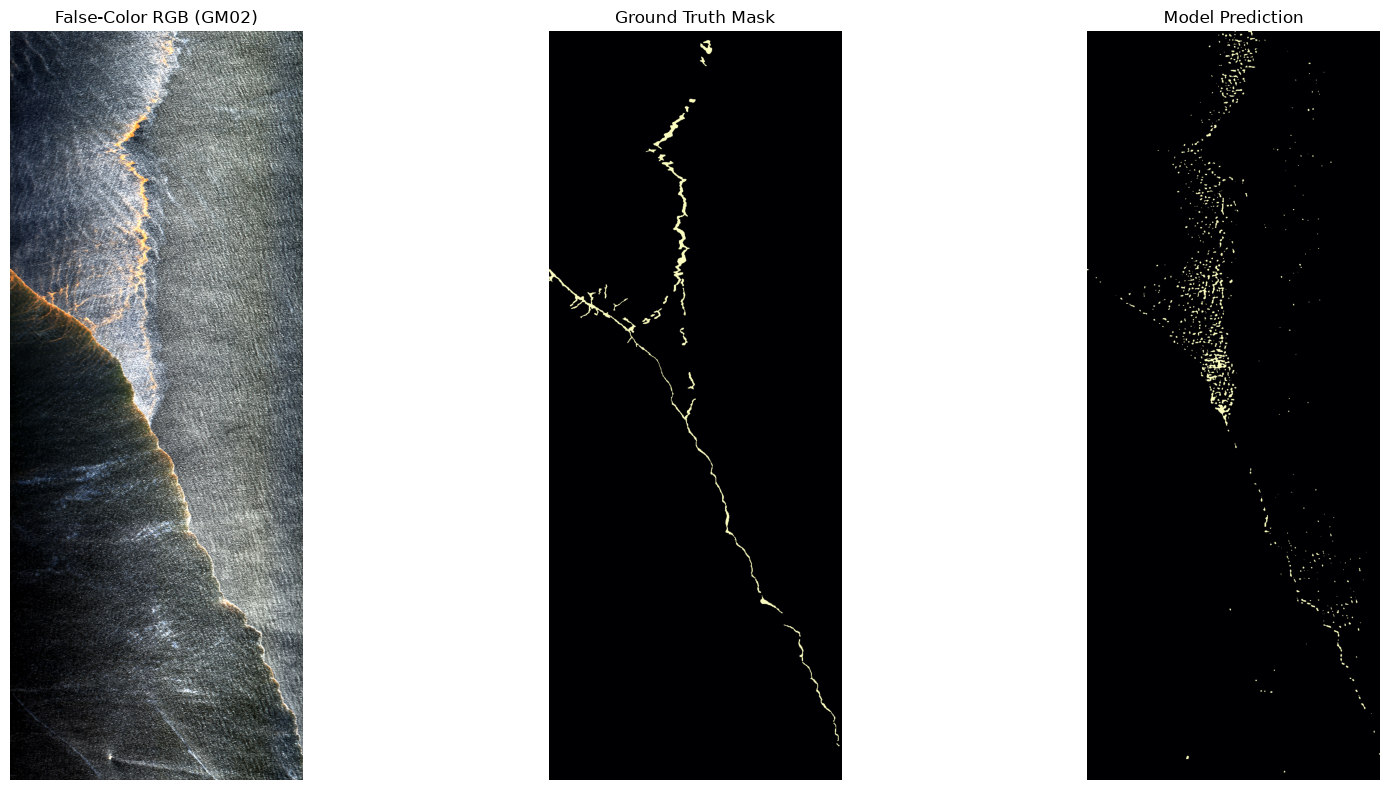

In [ ]:
def get_enhanced_rgb(img_array, rgb_bands=[29, 19, 9]):
    """
    Extracts and enhances RGB bands from the raw hyperspectral image.
    Red, Green, Blue bands (approx ~650nm, ~550nm, ~480nm in AVIRIS)
    """
    rgb_raw = img_array[:, :, rgb_bands].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    
    rgb_enhanced = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (2, 98))
        rgb_enhanced[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    return rgb_enhanced

def plot_full_scene(model, file_path, clean_bands, device, patch_size=11):
    mat = sio.loadmat(file_path)
    img = mat["img"]
    gt = mat["map"]
    
    # Extract RGB bands (approx ~650nm, ~550nm, ~480nm)
    rgb_raw = img[:, :, [29, 19, 9]].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    rgb_img = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (2, 98))
        rgb_img[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
    
    # Process hyperspectral data
    img_clean = img[:, :, clean_bands].astype(np.float32)
    img_clean = (img_clean - np.min(img_clean)) / (np.max(img_clean) - np.min(img_clean) + 1e-8)
    pad = patch_size // 2
    img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
    
    H, W = gt.shape
    raw_prob_map = np.zeros((H, W))
    valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
    
    batch_size = 512 
    model.eval()
    
    with torch.inference_mode():
        for i in tqdm(range(0, len(valid_coords), batch_size), desc=f"Inferring {file_path.stem}"):
            batch_coords = valid_coords[i:i+batch_size]
            batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
            
            batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
            probs = torch.sigmoid(model(batch_tensor)).cpu().numpy()
            
            # Populate the continuous probability map
            for (r, c), prob in zip(batch_coords, probs):
                raw_prob_map[r, c] = prob

    # Apply ERW spatial optimization
    print("Applying Extended Random Walker Optimization...")
    optimized_probs = apply_erw_optimization(raw_prob_map, rgb_img)
    
    # Calculate final binary predictions
    predictions = (optimized_probs > 0.5).astype(int)
    
    # Extract metrics using the valid coordinates
    all_probs = [optimized_probs[r, c] for r, c in valid_coords]
    all_targets = [gt[r, c] for r, c in valid_coords]
    preds_binary = (np.array(all_probs) > 0.5).astype(int)
    
    auc = roc_auc_score(all_targets, all_probs)
    precision = precision_score(all_targets, preds_binary, zero_division=0)
    recall = recall_score(all_targets, preds_binary, zero_division=0)
    f1 = f1_score(all_targets, preds_binary, zero_division=0)
    
    print(f"\n--- Full Scene Metrics for {file_path.stem} ---")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}\n")

    # Visual Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"False-Color RGB ({file_path.stem})")
    
    axs[1].imshow(gt == 1, cmap='magma')
    axs[1].set_title("Ground Truth Mask")
    
    axs[2].imshow(predictions, cmap='magma')
    axs[2].set_title("Model Prediction (ERW Optimized)")
    
    for ax in axs: 
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run the evaluation
plot_full_scene(model, test_files[0], CLEAN_BANDS, device)